In [ ]:
#Part- 3
#Advanced Modeling — Ensembles, Tuning, and Full ML Pipeline (25 marks)
# Import libraries

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from imblearn.over_sampling import SMOTE

In [ ]:
# Load cleaned dataset
df = pd.read_csv("stroke_cleaned_data.csv")

# Regression label
y_reg = df["avg_glucose_level"]

# Classification label
y_clf = df["stroke"]

#Since stroke is already a meaningful binary target, it is the best choice.
#There's no need to artificially create a binary label by splitting avg_glucose_level at its median.


# Feature matrix
X = df.drop(columns=["avg_glucose_level", "stroke"])

# check the shapes

print("Feature Matrix (X):", X.shape)
print("Regression Label (y_reg):", y_reg.shape)
print("Classification Label (y_clf):", y_clf.shape)

Feature Matrix (X): (5110, 9)
Regression Label (y_reg): (5110,)
Classification Label (y_clf): (5110,)


In [ ]:
#Encoding categorical columns

# Identify categorical columns
categorical_cols = [
    "gender",
    "ever_married",
    "work_type",
    "Residence_type",
    "smoking_status"
]

# Apply One-Hot Encoding

X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

#No label encoding was used because assigning integer values to these categories would create a false ordinal relationship.
#One-hot encoding represents each category as a separate binary feature, allowing machine learning models to treat the categories
#independently.
#The first dummy variable for each categorical feature was dropped (drop_first=True)
#to avoid multicollinearity (the dummy variable trap).


# Verify the encoded dataset

print("Encoded Feature Matrix Shape:", X.shape)
print("\nRemaining Data Types:")
print(X.dtypes)

print("\nFirst 5 Rows:")
print(X.head())

Encoded Feature Matrix Shape: (5110, 15)

Remaining Data Types:
age                               float64
hypertension                        int64
heart_disease                       int64
bmi                               float64
gender_Male                          bool
gender_Other                         bool
ever_married_Yes                     bool
work_type_Never_worked               bool
work_type_Private                    bool
work_type_Self-employed              bool
work_type_children                   bool
Residence_type_Urban                 bool
smoking_status_formerly smoked       bool
smoking_status_never smoked          bool
smoking_status_smokes                bool
dtype: object

First 5 Rows:
    age  hypertension  heart_disease   bmi  gender_Male  gender_Other  \
0  67.0             0              1  36.6         True         False   
1  61.0             0              0  28.1        False         False   
2  80.0             0              1  32.5         True   

In [ ]:
#Leak-free train-test split and scaling
# ----------------------------------------
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X,
    y_clf,
    test_size=0.2,
    random_state=42
)

scaler_clf = StandardScaler()

X_train_clf_scaler = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaler= scaler_clf.transform(X_test_clf)


print("\nClassification")
print("X_train:", X_train_clf.shape)
print("X_test :", X_test_clf.shape)
print("y_train:", y_train_clf.shape)
print("y_test :", y_test_clf.shape)


Classification
X_train: (4088, 15)
X_test : (1022, 15)
y_train: (4088,)
y_test : (1022,)


In [ ]:
from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE only on the training data
X_train_smote, y_train_smote = smote.fit_resample(X_train_clf_scaler, y_train_clf)

# Verify the new class distribution
print(y_train_smote.value_counts())

stroke
0    3901
1    3901
Name: count, dtype: int64


In [ ]:
# Import required libraries
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

# Train Logistic Regression on the SMOTE-resampled training data
log_reg = LogisticRegression(max_iter=1000, random_state=42)

log_reg.fit(X_train_smote, y_train_smote)

# Predict class labels using the SCALED test data
y_pred = log_reg.predict(X_test_clf_scaler)

# Predict probabilities (used for ROC-AUC later if needed)
y_pred_prob = log_reg.predict_proba(X_test_clf_scaler)[:, 1]

# Accuracy
accuracy = accuracy_score(y_test_clf, y_pred)
print("\nAccuracy:", accuracy)



Accuracy: 0.7475538160469667


In [ ]:
#Task - 1:
#Decision Tree baseline

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Train Decision Tree (default max_depth=None)
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train_clf_scaler, y_train_clf)

# Training predictions
y_train_pred = dt_model.predict(X_train_clf_scaler)

# Test predictions
y_test_pred = dt_model.predict(X_test_clf_scaler)

# Training accuracy
train_accuracy = accuracy_score(y_train_clf, y_train_pred)

# Test accuracy
test_accuracy = accuracy_score(y_test_clf, y_test_pred)

print("Training Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

Training Accuracy: 0.9997553816046967
Test Accuracy: 0.9041095890410958


In [ ]:
#Task - 2
#Controlled Decision Tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Controlled Decision Tree
dt_controlled = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    random_state=42
)

# Train the model
dt_controlled.fit(X_train_clf_scaler, y_train_clf)

# Predictions
y_train_pred = dt_controlled.predict(X_train_clf_scaler)
y_test_pred = dt_controlled.predict(X_test_clf_scaler)

# Accuracy
train_accuracy = accuracy_score(y_train_clf, y_train_pred)
test_accuracy = accuracy_score(y_test_clf, y_test_pred)

print("Training Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

Training Accuracy: 0.9547455968688845
Test Accuracy: 0.9393346379647749


In [ ]:
#Task - 3
#Gini vs Entropy comparison
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Decision Tree using Gini
dt_gini = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    random_state=42
)

dt_gini.fit(X_train_clf_scaler, y_train_clf)

y_pred_gini = dt_gini.predict(X_test_clf_scaler)

gini_accuracy = accuracy_score(y_test_clf, y_pred_gini)


# Decision Tree using Entropy
dt_entropy = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    random_state=42
)

dt_entropy.fit(X_train_clf_scaler, y_train_clf)

y_pred_entropy = dt_entropy.predict(X_test_clf_scaler)

entropy_accuracy = accuracy_score(y_test_clf, y_pred_entropy)


print("Gini Test Accuracy :", gini_accuracy)
print("Entropy Test Accuracy :", entropy_accuracy)

Gini Test Accuracy : 0.9373776908023483
Entropy Test Accuracy : 0.9393346379647749


In [ ]:
#Task - 4
#Random Forest

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
import pandas as pd

# Train Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf.fit(X_train_clf_scaler, y_train_clf)

# Predictions
y_train_pred = rf.predict(X_train_clf_scaler)
y_test_pred = rf.predict(X_test_clf_scaler)
y_test_prob = rf.predict_proba(X_test_clf_scaler)[:, 1]

# Metrics
train_accuracy = accuracy_score(y_train_clf, y_train_pred)
test_accuracy = accuracy_score(y_test_clf, y_test_pred)
roc_auc = roc_auc_score(y_test_clf, y_test_prob)

print("Training Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)
print("ROC-AUC:", roc_auc)

# Feature Importance
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

# Top 5 Features
top5 = feature_importance.sort_values(
    by="Importance",
    ascending=False
).head(5)

print("\nTop 5 Important Features")
print(top5)

Training Accuracy: 0.9655088062622309
Test Accuracy: 0.9393346379647749
ROC-AUC: 0.8243531586021506

Top 5 Important Features
                 Feature  Importance
0                    age    0.343314
3                    bmi    0.324564
11  Residence_type_Urban    0.043853
2          heart_disease    0.041768
1           hypertension    0.041238


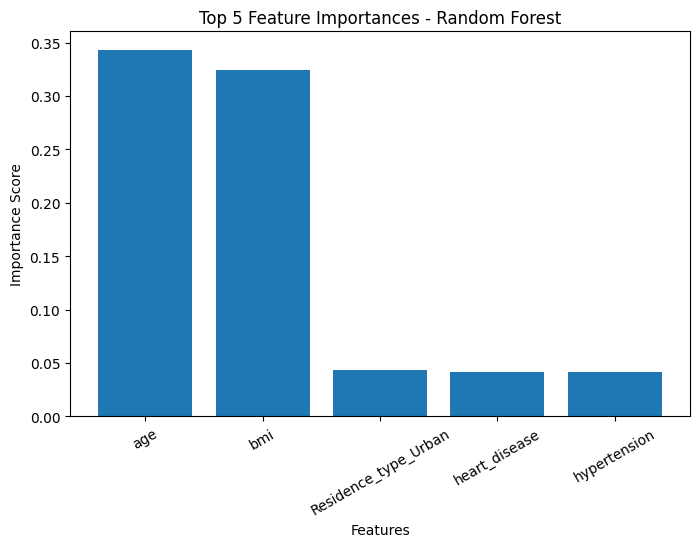

In [ ]:
#Visualization of feature importance:
import matplotlib.pyplot as plt
import pandas as pd

# Create DataFrame of feature importances
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Plot Top 5 Features
top5 = feature_importance.head(5)

plt.figure(figsize=(8,5))
plt.bar(top5["Feature"], top5["Importance"])

plt.title("Top 5 Feature Importances - Random Forest")
plt.xlabel("Features")
plt.ylabel("Importance Score")

plt.xticks(rotation=30)

# Save the figure
plt.savefig("random_forest_feature_importance.png", dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
#Task - 4a
#GradientBoostingClassifier

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

# Gradient Boosting Classifier
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Train the model
gb_model.fit(X_train_clf_scaler, y_train_clf)

# Predictions
y_train_pred = gb_model.predict(X_train_clf_scaler)
y_test_pred = gb_model.predict(X_test_clf_scaler)

# Prediction probabilities
y_test_prob = gb_model.predict_proba(X_test_clf_scaler)[:, 1]

# Evaluation
train_accuracy = accuracy_score(y_train_clf, y_train_pred)
test_accuracy = accuracy_score(y_test_clf, y_test_pred)
roc_auc = roc_auc_score(y_test_clf, y_test_prob)

print("Training Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)
print("ROC-AUC:", roc_auc)

Training Accuracy: 0.9579256360078278
Test Accuracy: 0.9393346379647749
ROC-AUC: 0.839020497311828


In [ ]:
#Task - 4b
#Feature abilation study:
print(type(X_train_clf_scaler))

<class 'numpy.ndarray'>


Random Forest reports feature importance using feature names (like age, bmi, etc.), but after scaling, the data became a NumPy array, which has no column names. Converting it back to a DataFrame lets we remove columns by name while keeping the scaled values.

In [ ]:
#Convert to DataFrame first
import pandas as pd

# Convert scaled arrays to DataFrames
X_train_scaled_df = pd.DataFrame(
    X_train_clf_scaler,
    columns=X.columns
)

X_test_scaled_df = pd.DataFrame(
    X_test_clf_scaler,
    columns=X.columns
)

#Find the 5 least important features

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=True
)

lowest5 = feature_importance.head(5)

print(lowest5)

#Remove those features

features_to_remove = lowest5["Feature"].tolist()

X_train_reduced = X_train_scaled_df.drop(
    columns=features_to_remove
)

X_test_reduced = X_test_scaled_df.drop(
    columns=features_to_remove
)



                           Feature  Importance
5                     gender_Other    0.000000
7           work_type_Never_worked    0.000123
10              work_type_children    0.002278
12  smoking_status_formerly smoked    0.020535
14           smoking_status_smokes    0.023217


In [ ]:
# Train the reduced Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score


rf_reduced = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf_reduced.fit(X_train_reduced, y_train_clf)

#Compare ROC-AUC

# Full model
y_prob_full = rf.predict_proba(X_test_clf_scaler)[:, 1]
auc_full = roc_auc_score(y_test_clf, y_prob_full)

# Reduced model
y_prob_reduced = rf_reduced.predict_proba(X_test_reduced)[:, 1]
auc_reduced = roc_auc_score(y_test_clf, y_prob_reduced)

print("Full Model ROC-AUC :", auc_full)
print("Reduced Model ROC-AUC :", auc_reduced)

Full Model ROC-AUC : 0.8243531586021506
Reduced Model ROC-AUC : 0.8269069220430108


In [ ]:
#Task - 5
#Cross-validated comparison for four models

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


# 5-Fold Stratified Cross Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Models
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree (max_depth=5)": DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )
}

results = []

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train_clf_scaler,
        y_train_clf,
        cv=cv,
        scoring="roc_auc"
    )

    results.append([
        name,
        scores.mean(),
        scores.std()
    ])

# Display results
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Mean ROC-AUC",
        "Std Dev"
    ]
)

print(results_df)

                         Model  Mean ROC-AUC   Std Dev
0          Logistic Regression      0.831558  0.010732
1  Decision Tree (max_depth=5)      0.756627  0.032716
2                Random Forest      0.773791  0.013642
3            Gradient Boosting      0.815783  0.008707


In [ ]:
# Task 6: Hyperparameter Tuning with GridSearchCV (Random Forest)

import pandas as pd
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score

# Step 1: Create Pipeline
pipeline = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler(),
    RandomForestClassifier(random_state=42)
)

# Step 2: Define Parameter Grid
param_grid = {
    'randomforestclassifier__n_estimators': [50, 100, 200],
    'randomforestclassifier__max_depth': [5, 10, None],
    'randomforestclassifier__min_samples_leaf': [1, 5]
}

# Step 3: Stratified 5-Fold Cross Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Step 4: Perform Grid Search
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

# Step 5: Train Grid Search
grid_search.fit(X_train_clf, y_train_clf)

# Step 6: Get Best Pipeline
best_pipeline = grid_search.best_estimator_

# Step 7: Predict on Test Data
y_pred_prob = best_pipeline.predict_proba(X_test_clf)[:, 1]

# Step 8: Calculate Test ROC-AUC
test_auc = roc_auc_score(y_test_clf, y_pred_prob)

# Step 9: Display Results
cv_results = pd.DataFrame(grid_search.cv_results_)
best_result = cv_results.loc[grid_search.best_index_]

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Mean ROC-AUC:")
print(best_result["mean_test_score"])

print("\nBest Std ROC-AUC:")
print(best_result["std_test_score"])

print("\nTest ROC-AUC:")
print(test_auc)

Best Parameters:
{'randomforestclassifier__max_depth': 5, 'randomforestclassifier__min_samples_leaf': 5, 'randomforestclassifier__n_estimators': 200}

Best Mean ROC-AUC:
0.8237432869790171

Best Std ROC-AUC:
0.011138140968092328

Test ROC-AUC:
0.8573504704301076


In [ ]:
#Task - 7
#Manual learning curve
import pandas as pd
from sklearn.base import clone
from sklearn.metrics import roc_auc_score

# Best Random Forest model from GridSearchCV
best_rf = grid_search.best_estimator_

# Training fractions
fractions = [0.2, 0.4, 0.6, 0.8, 1.0]

results = []

for f in fractions:

    # Number of training samples
    n_samples = int(f * len(X_train_clf_scaler))

    # Take the first n_samples
    X_subset = X_train_clf_scaler[:n_samples]
    y_subset = y_train_clf[:n_samples]

    # Clone the best model so each iteration starts fresh
    model = clone(best_rf)

    # Train on the subset
    model.fit(X_subset, y_subset)

    # -------------------------
    # Training AUC
    # -------------------------
    train_prob = model.predict_proba(X_subset)[:, 1]
    train_auc = roc_auc_score(y_subset, train_prob)

    # -------------------------
    # Test AUC
    # -------------------------
    test_prob = model.predict_proba(X_test_clf_scaler)[:, 1]
    test_auc = roc_auc_score(y_test_clf, test_prob)

    # Save results
    results.append({
        "Training Fraction": f,
        "Training AUC": train_auc,
        "Test AUC": test_auc
    })

# Create DataFrame
learning_curve_df = pd.DataFrame(results)

# Display results
print(learning_curve_df)

   Training Fraction  Training AUC  Test AUC
0                0.2      0.921813  0.822992
1                0.4      0.910722  0.822035
2                0.6      0.897920  0.848614
3                0.8      0.885542  0.855780
4                1.0      0.883195  0.857350


In [ ]:
#Task - 7
#Serialize the best model
import joblib

# Best model from GridSearchCV
best_pipeline = grid_search.best_estimator_

# Save the best model
joblib.dump(best_pipeline, "best_model.pkl")

print("Best model saved as best_model.pkl")

joblib.dump(best_pipeline, "best_model.pkl")

Best model saved as best_model.pkl


['best_model.pkl']

In [ ]:
from google.colab import files

files.download("best_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Load the saved pipeline
loaded_model = joblib.load("best_model.pkl")

# Two hand-crafted examples
sample_data = pd.DataFrame([
    [65, 1, 1, 32.5, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0],
    [28, 0, 0, 23.4, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0]
], columns=[
    'age',
    'hypertension',
    'heart_disease',
    'bmi',
    'gender_Male',
    'gender_Other',
    'ever_married_Yes',
    'work_type_Never_worked',
    'work_type_Private',
    'work_type_Self-employed',
    'work_type_children',
    'Residence_type_Urban',
    'smoking_status_formerly smoked',
    'smoking_status_never smoked',
    'smoking_status_smokes'
])

# Predict directly (the pipeline handles preprocessing)
predictions = loaded_model.predict(sample_data)

for i, pred in enumerate(predictions, start=1):
    result = "Stroke" if pred == 1 else "No Stroke"
    print(f"Sample {i}: {result}")

print("Predictions:")
print(predictions)

In [ ]:
from sklearn.metrics import roc_auc_score
import pandas as pd

# Calculate Test ROC-AUC for all baseline models

log_reg_test_auc = roc_auc_score(
    y_test_clf,
    log_reg.predict_proba(X_test_clf_scaler)[:, 1]
)


dt_model_test_auc = roc_auc_score(
    y_test_clf,
    dt_model.predict_proba(X_test_clf_scaler)[:, 1]
)

rf_test_auc = roc_auc_score(
    y_test_clf,
    rf.predict_proba(X_test_clf_scaler)[:, 1]
)

gb_model_test_auc = roc_auc_score(
    y_test_clf,
    gb_model.predict_proba(X_test_clf_scaler)[:, 1]
)


# Display results
test_auc_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Test ROC-AUC": [
        log_reg_test_auc,
        dt_model_test_auc,
        rf_test_auc,
        gb_model_test_auc
    ]
})

print(test_auc_df)

Task - 9
Summary comparison table

Model Comparison

| Model                       | 5-Fold CV Mean ROC-AUC | 5-Fold CV Std ROC-AUC | Test ROC-AUC |
| --------------------------- | ---------------------- | --------------------- | ------------ |
| Logistic Regression         | 0.8316                 | 0.0107                | 0.8465       |
| Decision Tree (max_depth=5) | 0.7566                 | 0.0327                | 0.5718       |
| Random Forest               | 0.7738                 | 0.0136                | 0.8244       |
| Gradient Boosting           | 0.8158                 | 0.0087                | 0.8390       |
| Tuned Random Forest         | **0.8237**             | **0.0111**            | **0.8574**   |

## Recommended Model

I recommend the **Tuned Random Forest** because it achieved the highest **test ROC-AUC (0.8574)** among all the models. Hyperparameter tuning improved its performance compared to the baseline Random Forest (from 0.8244 to 0.8574). This model performed the best on unseen data, making it the most suitable choice for stroke prediction.


